# Assignment 2: Milestone I Natural Language Processing
## Task 2&3
#### Student Name: XXXX XXXX
#### Student ID: 000000


Environment: Python 3 and Jupyter notebook

Libraries used: please include all the libraries you used in your assignment, e.g.,:
* pandas
* re
* numpy

## Introduction
You should give a brief information of this assessment task here.

<span style="color: red"> Note that this is a sample notebook only. You will need to fill in the proper markdown and code blocks. You might also want to make necessary changes to the structure to meet your own needs. Note also that any generic comments written in this notebook are to be removed and replace with your own words.</span>

## Install fasttest used for vector embedding

## Importing and install libraries 

In [20]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
# load file glove
path_to_glove_file = os.path.join("glove", "glove.6B.100d.txt")

# create dict - word vectors
glove_wv = {}

with open(path_to_glove_file, encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word = parts[0]
        coefs = np.asarray(parts[1:], dtype="float32")
        glove_wv[word] = coefs

print("Found %s word vectors." % len(glove_wv))

# testing - print
print(glove_wv["king"][:10])  # in ra 10 giá trị đầu của vector 'king'


Found 400000 word vectors.
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ]


## Task 2. Generating Feature Representations for Clothing Items Reviews

...... Sections and code blocks on buidling different document feature represetations


<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

### Load neccessary csv 
processed.csv

In [7]:
# Code to perform the task...
# === Task 2: Bag-of-Words ===

# Load processed.csv (must contain column 'tokens' from Task 1)
df = pd.read_csv("processed.csv")

# Convert 'tokens' from string to list if needed
print("[OK] processed.csv loaded. Rows:", len(df))

[OK] processed.csv loaded. Rows: 19662


### Building the Vocabulary Dictionary

reading the vocabulary.txt file and building a dictionary that maps each word to its index.

In [8]:
# === Task 2: Bag-of-Words ===
word2idx = {}
with open("vocabulary.txt", "r", encoding="utf-8") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        w, sidx = s.rsplit(":", 1)
        word2idx[w] = int(sidx)

print("vocabulary.txt loaded. Size:", len(word2idx))
print("Sample entries:", list(word2idx.items())[:5])

vocabulary.txt loaded. Size: 7529
Sample entries: [('a-cup', 0), ('a-flutter', 1), ('a-frame', 2), ('a-kind', 3), ('a-line', 4)]


### Saving outputs
Save the count vector representation as per spectification.
- count_vectors.txt

In [10]:
# code to save output data...
# === Task 2: Bag-of-Words ===
from collections import Counter
import ast

out_path = "count_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, tokens in enumerate(df["tokens"].values):
        ctr = Counter()
        tokens = ast.literal_eval(tokens)
        for t in tokens:
            idx = word2idx.get(t)
            if idx is not None:
                ctr[idx] += 1

        # Format: "#<review_index>,idx:count,idx:count,..."
        
        parts = [f"{i}:{ctr[i]}" for i in sorted(ctr)]
        fout.write(f"#{review_index},{','.join(parts)}\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to count_vectors.txt
#0,686:1,1027:1,1715:1,1791:1,2288:1,2481:1,2602:1,2892:2,3010:1,3087:1,3193:1,3258:1,3549:2,3552:1,3832:1,3934:1,4224:2,4234:1,4427:1,4639:2,5260:1,5668:1,6726:1,7092:1,7207:1,7406:1,7520:1,7522:1
#1,1286:1,2283:1,2502:1,2667:1,3403:1,6739:1
#2,86:1,924:1,1987:1,2646:1,3584:1,3595:1,4506:1,5736:2,5924:1,6716:1


### Extract the feature vector for each review
#### Unweigted Fasttext model

##### Print out dataframe tokens column's type

In [11]:
print(type(df['tokens'].iloc[0]))

<class 'str'>


##### Create a corpus file  
The corpus file represents distinct words of tokens, which will be used in the following steps.

In [12]:
with open("corpus.txt", "w", encoding="utf-8") as f:
    for tokens_str in df['tokens']:
        tokens_list = ast.literal_eval(tokens_str)
        f.write(" ".join(tokens_list) + "\n")

Now we train the skipgram fasttext model based on the corpus file

In [13]:
# === Load pretrained GloVe vectors from local file ===
path_to_glove_file = os.path.join('glove', 'glove.6B.100d.txt')
glove_wv = {}
with open(path_to_glove_file, encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        word, coefs = parts[0], np.asarray(parts[1:], dtype='float32')
        glove_wv[word] = coefs
print('Found %s word vectors.' % len(glove_wv))


Found 400000 word vectors.


Try to print out sentence vector of one line to see the format

In [16]:
sentence = df['tokens'].iloc[0]          # lấy 1 dòng tokens (string)
tokens = ast.literal_eval(sentence)      # convert string -> list
vecs = [glove_wv[t] for t in tokens if t in glove_wv]

print("Sentence length:", len(tokens))
print("Vector shape:", vecs[0].shape if vecs else "OOV only")
print("Mean pooled vector:", np.mean(vecs, axis=0))

Sentence length: 32
Vector shape: (100,)
Mean pooled vector: [-2.37603962e-01  1.87611982e-01  2.06782848e-01 -1.72068402e-01
  6.61378056e-02  1.36691332e-02 -2.33567227e-02  1.40242264e-01
 -2.55546463e-03  2.42306277e-01  1.41616151e-01  1.25330091e-02
  1.93498850e-01  1.08647849e-02  1.96627885e-01 -4.82560620e-02
  4.99383407e-03  3.68231684e-02  7.15183616e-02 -1.06607646e-01
  1.03885695e-01  5.64851873e-02  1.00387305e-01 -3.86443082e-03
  2.11305186e-01 -1.03310585e-01 -1.18373983e-01 -3.17010999e-01
 -2.63772845e-01 -2.59434611e-01  3.39593329e-02  2.22990528e-01
 -8.36506262e-02 -2.30186611e-01  1.45958006e-01  1.70477778e-01
  1.00440197e-02  6.75151944e-02  1.63908079e-02 -8.94875526e-02
  8.85799080e-02 -4.08290982e-01 -3.43823247e-02  2.66765319e-02
 -4.74542156e-02  7.01193810e-02  1.43701673e-01  3.43122631e-02
  2.44205575e-02 -2.67926276e-01 -9.67212580e-03 -1.35283088e-02
  1.20197330e-03  6.48148775e-01 -2.77351230e-01 -1.41940284e+00
 -4.49149050e-02 -1.20975658e

Save the result to a column

In [17]:
def get_review_vector(tokens):
    import ast, numpy as np
    if isinstance(tokens, str):
        try:
            tokens = ast.literal_eval(tokens)
        except Exception:
            tokens = tokens.split()
    vecs = []
    for t in tokens:
        if t in glove_wv:
            vecs.append(glove_wv[t])
    if not vecs:
        return np.zeros(100, dtype=np.float32)  # glove.6B.100d
    return np.mean(vecs, axis=0)

df['unweighted_vector'] = df['tokens'].apply(get_review_vector)
df


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,tokens,unweighted_vector
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,"['high', 'hopes', 'wanted', 'work', 'initially...","[-0.23760396, 0.18761198, 0.20678285, -0.17206..."
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"['jumpsuit', 'fun', 'flirty', 'fabulous', 'tim...","[0.021367168, 0.08125416, 0.25918934, -0.41787..."
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,"['shirt', 'due', 'adjustable', 'front', 'tie',...","[-0.25033528, 0.2758961, -0.016397955, -0.2584..."
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,"['tracy', 'reese', 'dresses', 'petite', 'feet'...","[-0.10872854, 0.2759528, -0.018244764, -0.1314..."
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,"['basket', 'hte', 'person', 'store', 'pick', '...","[0.030028105, 0.033884652, 0.19390146, -0.1049..."
...,...,...,...,...,...,...,...,...,...,...,...,...
19657,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses,"['happy', 'snag', 'price', 'easy', 'slip', 'cu...","[-0.22098558, 0.103867136, 0.3574267, -0.20418..."
19658,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits,"['reminds', 'maternity', 'clothes', 'stretchy'...","[-0.26693833, 0.25673, 0.13334382, -0.23989077..."
19659,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses,"['worked', 'glad', 'store', 'order', 'online']","[0.13308859, -0.10536901, -0.23911801, -0.1431..."
19660,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses,"['wedding', 'summer', 'medium', 'fits', 'waist...","[-0.09231853, 0.31047457, 0.092624955, -0.2795..."


Save to a txt file with correct format

In [18]:
out_path = "unweighted_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, vec_str in enumerate(df["unweighted_vector"].values):
        # Convert string "[0.1, 0.2, ...]" into Python list
        fout.write(f"#{review_index}," + ",".join(map(str, vec_str)) + "\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")

# Preview first 3 lines
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to unweighted_vectors.txt
#0,-0.23760396,0.18761198,0.20678285,-0.1720684,0.066137806,0.013669133,-0.023356723,0.14024226,-0.0025554646,0.24230628,0.14161615,0.012533009,0.19349885,0.010864785,0.19662789,-0.048256062,0.004993834,0.03682317,0.07151836,-0.106607646,0.103885695,0.056485187,0.100387305,-0.0038644308,0.21130519,-0.103310585,-0.11837398,-0.317011,-0.26377285,-0.2594346,0.033959333,0.22299053,-0.083650626,-0.23018661,0.145958,0.17047778,0.01004402,0.067515194,0.016390808,-0.08948755,0.08857991,-0.40829098,-0.034382325,0.026676532,-0.047454216,0.07011938,0.14370167,0.034312263,0.024420558,-0.26792628,-0.009672126,-0.013528309,0.0012019733,0.6481488,-0.27735123,-1.4194028,-0.044914905,-0.12097566,1.0273924,0.27708954,-0.015232429,0.46509483,-0.28807396,0.28440678,0.42010897,-0.15783072,0.27401406,0.048359454,0.19374979,-0.16660035,0.1522823,0.07873588,0.21465537,-0.06767161,0.18353307,0.03527253,-0.12971905,-0.099967346,-0.07477972,0.109782934,0.30322924,

Reload the corpus for TF-IDF fit transformation

In [21]:
# load corpus into sentences for vectorizer
with open("corpus.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip() for line in f]

# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(sentences)
tfidf_matrix = tfidf_vectorizer.transform(sentences)

Use TF-IDF weight to vectorize the tokens

In [23]:
# Map token indices to their corresponding tokens
index_to_token = {j: t for t, j in tfidf_vectorizer.vocabulary_.items()}

# Get the embedding dimension from the model
embedding_dimension = 100

# Create a weight matrix for the embeddings
weight_matrix = np.zeros((tfidf_matrix.shape[0], embedding_dimension))

for i in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix.getrow(i)
    if row.nnz == 0:
        continue

    vector_sum = np.zeros(embedding_dimension, dtype=np.float32)
    weight_sum = 0.0

    # Compute the weighted sum of word vectors
    for j, w in zip(row.indices, row.data):
        token = index_to_token[j]
        if token in glove_wv:
            vec = glove_wv[token]
        else:
            continue
        vector_sum += vec * float(w)
        weight_sum += float(w)

    # Normalize the vector by the weight sum
    if weight_sum > 0:
        weight_matrix[i] = vector_sum / weight_sum



Save the result

In [24]:
df["weighted_vector"] = [vec.tolist() for vec in weight_matrix]
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,tokens,unweighted_vector,weighted_vector
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,"['high', 'hopes', 'wanted', 'work', 'initially...","[-0.23760396, 0.18761198, 0.20678285, -0.17206...","[-0.1887836456298828, 0.1766006499528885, 0.26..."
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"['jumpsuit', 'fun', 'flirty', 'fabulous', 'tim...","[0.021367168, 0.08125416, 0.25918934, -0.41787...","[0.04194686561822891, 0.07756645977497101, 0.2..."
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,"['shirt', 'due', 'adjustable', 'front', 'tie',...","[-0.25033528, 0.2758961, -0.016397955, -0.2584...","[-0.2699391543865204, 0.2768770456314087, 0.02..."
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,"['tracy', 'reese', 'dresses', 'petite', 'feet'...","[-0.10872854, 0.2759528, -0.018244764, -0.1314...","[-0.08016244322061539, 0.2749248147010803, 0.0..."
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,"['basket', 'hte', 'person', 'store', 'pick', '...","[0.030028105, 0.033884652, 0.19390146, -0.1049...","[0.014811047352850437, 0.005885071121156216, 0..."


In [25]:
out_path = "weighted_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, vec_str in enumerate(df["weighted_vector"].values):
        # Convert string "[0.1, 0.2, ...]" into Python list
        fout.write(f"#{review_index}," + ",".join(map(str, vec_str)) + "\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")

# Preview first 3 lines
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to weighted_vectors.txt
#0,-0.1887836456298828,0.1766006499528885,0.2636432647705078,-0.18225115537643433,0.11733275651931763,0.012105117551982403,-0.04135465994477272,0.09285843372344971,0.03463256359100342,0.18924933671951294,0.17117397487163544,0.04706454277038574,0.19341780245304108,-0.0017253016121685505,0.21119974553585052,-0.056742530316114426,-0.04885637015104294,0.06952907890081406,0.07458405941724777,-0.11840248107910156,0.15797412395477295,0.062437355518341064,0.10496006160974503,0.09480715543031693,0.1535317301750183,-0.13734593987464905,-0.0966021716594696,-0.23461472988128662,-0.23601490259170532,-0.30053746700286865,0.07571728527545929,0.2540448307991028,-0.08431664109230042,-0.20261168479919434,0.13401050865650177,0.14410553872585297,-0.049132417887449265,0.05265539139509201,-0.04239019379019737,-0.06639812141656876,0.10774893313646317,-0.33479514718055725,-0.04224377125501633,0.04751844331622124,-0.06260554492473602,0.09199710190296173,0.13910938

## Task 3. Clothing Review Classification

...... Sections and code blocks on buidling classification models based on different document feature represetations. 
Detailed comparsions and evaluations on different models to answer each question as per specification. 

<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

In [26]:
# Code to perform the task...
def load_vectors(file_path, sparse=False):
    vectors = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(",", 1)
            if len(parts) < 2:
                continue
            vec_str = parts[1]
            if sparse:
                vec = {}
                for item in vec_str.split(","):
                    if ":" in item:
                        idx, val = item.split(":")
                        vec[int(idx)] = int(val)
                vectors.append(vec)
            else:
                vec = np.array([float(x) for x in vec_str.split(",")])
                vectors.append(vec)
    return vectors


In [27]:
from sklearn.preprocessing import StandardScaler


X_count     = load_vectors("count_vectors.txt", sparse=True)
X_unweighted = StandardScaler().fit_transform(np.array(load_vectors("unweighted_vectors.txt")))
X_weighted   = StandardScaler().fit_transform(np.array(load_vectors("weighted_vectors.txt")))

In [28]:
X_unweighted

array([[-0.51196315, -0.66591786,  0.62597053, ..., -0.61734652,
         0.13426098, -0.69130439],
       [ 1.34285921, -1.55727204,  1.01486381, ..., -0.10056378,
        -1.64406174,  2.49913917],
       [-0.60314836,  0.07396586, -1.03018914, ...,  1.418976  ,
         0.06638684, -3.33666094],
       ...,
       [ 2.14303872, -3.12130694, -2.68292972, ...,  1.30013626,
         1.0026396 ,  1.88421992],
       [ 0.52861101,  0.36375803, -0.22116192, ...,  0.42794623,
         0.83552638, -0.27429142],
       [-1.72972733,  0.29368213,  1.82328587, ..., -2.03868489,
        -1.96656773,  2.64603046]], shape=(19662, 100))

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(
        n_estimators=200,        # number of trees
        max_depth=None,          # let trees grow fully
        class_weight="balanced", # handle imbalance
        random_state=42,
        n_jobs=-1
)

In [30]:
y = df["Recommended IND"].values  

In [31]:
df["Recommended IND"].value_counts()

Recommended IND
1    16087
0     3575
Name: count, dtype: int64

In [32]:
print(X_unweighted)

[[-0.51196315 -0.66591786  0.62597053 ... -0.61734652  0.13426098
  -0.69130439]
 [ 1.34285921 -1.55727204  1.01486381 ... -0.10056378 -1.64406174
   2.49913917]
 [-0.60314836  0.07396586 -1.03018914 ...  1.418976    0.06638684
  -3.33666094]
 ...
 [ 2.14303872 -3.12130694 -2.68292972 ...  1.30013626  1.0026396
   1.88421992]
 [ 0.52861101  0.36375803 -0.22116192 ...  0.42794623  0.83552638
  -0.27429142]
 [-1.72972733  0.29368213  1.82328587 ... -2.03868489 -1.96656773
   2.64603046]]



=== Using Count Vectors ===
Accuracy: 0.876
              precision    recall  f1-score   support

           0      0.706     0.549     0.617      3575
           1      0.904     0.949     0.926     16087

    accuracy                          0.876     19662
   macro avg      0.805     0.749     0.772     19662
weighted avg      0.868     0.876     0.870     19662

Confusion Matrix:
[[ 1962  1613]
 [  819 15268]]


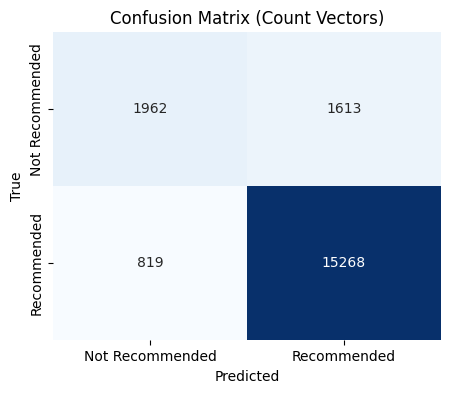


=== Using Unweighted Vectors ===
Accuracy: 0.842
              precision    recall  f1-score   support

           0      0.643     0.299     0.408      3575
           1      0.861     0.963     0.909     16087

    accuracy                          0.842     19662
   macro avg      0.752     0.631     0.659     19662
weighted avg      0.821     0.842     0.818     19662

Confusion Matrix:
[[ 1068  2507]
 [  592 15495]]


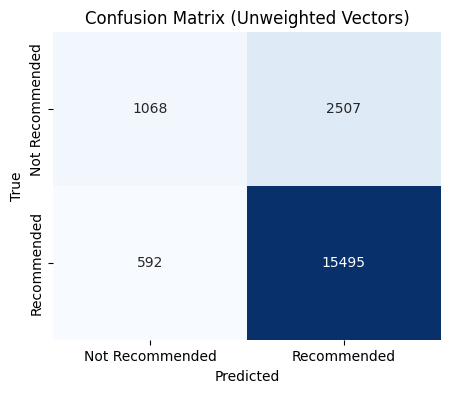


=== Using Weighted Vectors ===
Accuracy: 0.839
              precision    recall  f1-score   support

           0      0.634     0.267     0.376      3575
           1      0.856     0.966     0.907     16087

    accuracy                          0.839     19662
   macro avg      0.745     0.617     0.642     19662
weighted avg      0.815     0.839     0.811     19662

Confusion Matrix:
[[  956  2619]
 [  552 15535]]


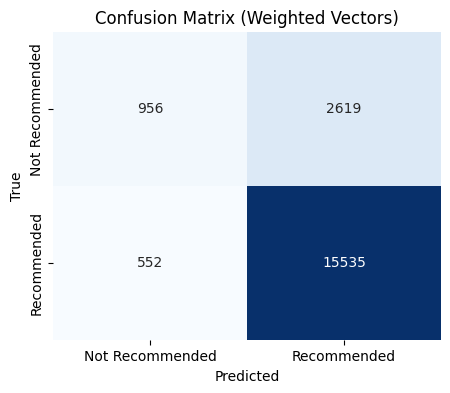

In [35]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


for name, X in [("Count", X_count), ("Unweighted", X_unweighted), ("Weighted", X_weighted)]:
    # if X_count is dict format, convert with DictVectorizer
    if name == "Count":
        vec = DictVectorizer(sparse=True)
        X = vec.fit_transform(X)

    print(f"\n=== Using {name} Vectors ===")
    y_pred = cross_val_predict(clf, X, y, cv=cv)
    # Accuracy
    acc = accuracy_score(y, y_pred)
    print(f"Accuracy: {acc:.3f}")
    
    # Detailed report
    print(classification_report(y, y_pred, digits=3))
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # --- Plot confusion matrix ---
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Not Recommended", "Recommended"],
                yticklabels=["Not Recommended", "Recommended"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix ({name} Vectors)")
    plt.show()

## Summary
Give a short summary and anything you would like to talk about the assessment tasks here.

## Couple of notes for all code blocks in this notebook
- please provide proper comment on your code
- Please re-start and run all cells to make sure codes are runable and include your output in the submission.   
<span style="color: red"> This markdown block can be removed once the task is completed. </span>